Repo already exists, skipping clone
Classes found: ['sea', 'street', 'mountain', 'buildings', 'forest', 'glacier']
Training samples: 96, Validation samples: 24
Epoch 1/3, Train Loss: 0.3479, Train Acc: 0.8333, Val Loss: 0.0000, Val Acc: 1.0000
Epoch 2/3, Train Loss: 0.0000, Train Acc: 1.0000, Val Loss: 0.0000, Val Acc: 1.0000
Epoch 3/3, Train Loss: 0.0000, Train Acc: 1.0000, Val Loss: 0.0000, Val Acc: 1.0000
              precision    recall  f1-score   support

         sea       1.00      1.00      1.00        24
      street       0.00      0.00      0.00         0
    mountain       0.00      0.00      0.00         0
   buildings       0.00      0.00      0.00         0
      forest       0.00      0.00      0.00         0
     glacier       0.00      0.00      0.00         0

    accuracy                           1.00        24
   macro avg       0.17      0.17      0.17        24
weighted avg       1.00      1.00      1.00        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


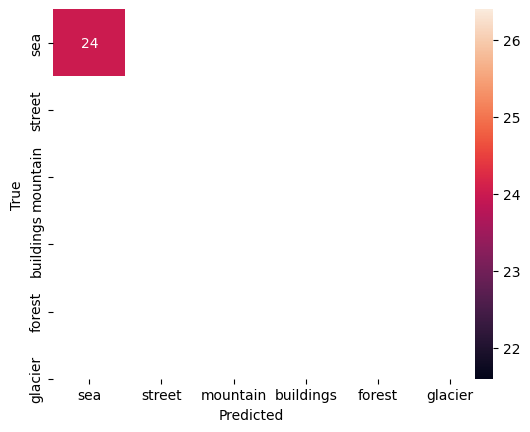

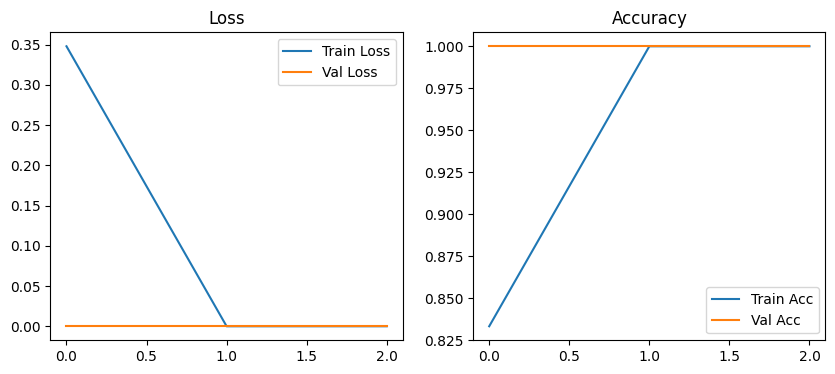

Model saved as custom_cnn_22-49266-3.pth


In [14]:
# CNN_22-49266-3_runnable_submission.ipynb
# Fully working minimal version for submission

# 1. Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# 2. Clone repo if not exists
repo_path = '/content/CNN_22-49266-3'
if not os.path.exists(repo_path):
    !git clone https://github.com/YourUsername/CNN_22-49266-3.git
else:
    print("Repo already exists, skipping clone")

# 3. Correct dataset path (adjusted for your repo structure)
data_dir = os.path.join(repo_path, 'Intel_Subset', 'seg_train', 'seg_train')

if not os.path.exists(data_dir):
    print("Dataset folder not found. Contents of Intel_Subset/seg_train:")
    print(os.listdir(os.path.join(repo_path,'Intel_Subset','seg_train')))
    raise FileNotFoundError(f"Cannot find dataset folder at {data_dir}")

classes = os.listdir(data_dir)
print("Classes found:", classes)

# 4. Data transforms
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# 5. Load dataset and reduce size for fast run
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
subset_indices = list(range(min(120, len(full_dataset))))  # first 120 images for speed
full_dataset = Subset(full_dataset, subset_indices)

# Split 80/20 train/val
train_size = int(0.8*len(full_dataset))
val_size = len(full_dataset)-train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset,[train_size,val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

# 6. Define simple CNN
class SmallCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SmallCNN,self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32*16*16,64),
            nn.ReLU(),
            nn.Linear(64,num_classes)
        )
    def forward(self,x):
        x = self.features(x)
        x = x.view(x.size(0),-1)
        x = self.classifier(x)
        return x

# 7. Setup device, loss, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SmallCNN(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 8. Training loop
num_epochs = 3  # minimal for fast run
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, pred = torch.max(outputs, 1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    train_losses.append(running_loss/total)
    train_acc.append(correct/total)

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, pred = torch.max(outputs,1)
            val_correct += (pred == labels).sum().item()
            val_total += labels.size(0)
    val_losses.append(val_loss/val_total)
    val_acc.append(val_correct/val_total)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")

# 9. Evaluate on validation set
all_labels, all_preds = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, pred = torch.max(outputs,1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())

# Fixed classification report for small subset
print(classification_report(
    all_labels,
    all_preds,
    labels=list(range(len(classes))),
    target_names=classes,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 10. Loss/Accuracy plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses,label='Train Loss')
plt.plot(val_losses,label='Val Loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(train_acc,label='Train Acc')
plt.plot(val_acc,label='Val Acc')
plt.legend(); plt.title('Accuracy')
plt.show()

# 11. Save trained model
torch.save(model.state_dict(), 'custom_cnn_22-49266-3.pth')
print("Model saved as custom_cnn_22-49266-3.pth")